# Data Miner 2 spike

One-sitting throwaway notebook to validate the API and resolve the open questions blocking real acquisition work. Read `docs/pjm-api-constraints.md` and `docs/decisions.md` first — the design of this spike is driven by those.

## Goals

1. **Auth smoke** — confirm the subscription key works and capture the actual JSON envelope shape (the API guide describes header behavior with `download=true` but doesn't pin down the body envelope without it).
2. **Resolve pnode IDs** for Pleasant View, Ashburn, Goose Creek (zone=DOM). This is the **primary deliverable** — every downstream pull needs these.
3. **Validate `rt_hrl_lmps`** with one day at one resolved pnode_id — confirm field shape and timezone.
4. **Validate `rt_fivemin_hrl_lmps`** with one day at one resolved pnode_id within the Standard window (last ~186 days). Confirms 5-min nodal works when filtered by `pnode_id` (zone filter is disabled on this feed).
5. **Validate `hrl_load_metered`** with one day of DOM-zone load.
6. **Capture any rate-limit headers** the API returns (the guide doesn't document a limit).
7. **Resize the bulk-pull estimates** against the actual scope from `decisions.md` (5-min = 6mo, hourly = 2yr, zonal older).

## Auth

Register at <https://apiportal.pjm.com>, subscribe to the *Data Miner Production* product, paste the primary key into `.env` as `PJM_API_KEY=...`. Anonymous calls return 401.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

import httpx
import pandas as pd
from dotenv import load_dotenv


def _find_project_root() -> Path:
    """Walk up from cwd looking for pyproject.toml — kernel-cwd-independent."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


PROJECT_ROOT = _find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_RAW.mkdir(parents=True, exist_ok=True)

env_path = PROJECT_ROOT / ".env"
loaded = load_dotenv(env_path)
print(f"[setup] cwd          = {Path.cwd()}")
print(f"[setup] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[setup] .env path    = {env_path}  (exists={env_path.exists()}, loaded={loaded})")

API_KEY = os.environ.get("PJM_API_KEY")
if not API_KEY:
    raise RuntimeError(
        f"PJM_API_KEY is not set after load_dotenv({env_path}).\n"
        "Confirm .env exists at PROJECT_ROOT and contains a line "
        "`PJM_API_KEY=<key>` (no quotes, no surrounding whitespace)."
    )
print(f"[setup] PJM_API_KEY loaded ({len(API_KEY)} chars)")

BASE_URL = "https://api.pjm.com/api/v1"
HEADERS = {"Ocp-Apim-Subscription-Key": API_KEY, "Accept": "application/json"}

# Free-tier rate limit: 6 calls/min (see docs/pjm-api-constraints.md).
# 11s spacing keeps us at ~5.5 calls/min with one slot of margin.
MIN_REQUEST_INTERVAL_S = 11.0
_last_request_ts = 0.0

# Spike target date: well within the 186-day Standard window for 5-min LMP
# (today minus 186 days ≈ 2025-11-05; we pick a date comfortably inside that).
SPIKE_DAY = "2026-04-15"
SPIKE_DAY_START = f"{SPIKE_DAY} 00:00"
SPIKE_DAY_END = f"{SPIKE_DAY} 23:59"

# Substation names from the proposal — partial-match against pnode_name
TARGET_SUBSTATIONS = ["Pleasant View", "Ashburn", "Goose Creek"]

[setup] cwd          = ~/docs/NU/Freshman_Year/Summer 2026/SURG/surg/notebooks
[setup] PROJECT_ROOT = ~/docs/NU/Freshman_Year/Summer 2026/SURG/surg
[setup] .env path    = ~/docs/NU/Freshman_Year/Summer 2026/SURG/surg/.env  (exists=True, loaded=True)
[setup] PJM_API_KEY loaded (32 chars)


## Paginated fetcher

Wraps the JSON envelope and pagination. Deliberately verbose on the first call so we can confirm the envelope key names empirically — the API guide doesn't pin them down for non-`download=true` responses.

In [2]:
def _throttle() -> None:
    """Block until at least MIN_REQUEST_INTERVAL_S has passed since last request."""
    global _last_request_ts
    elapsed = time.time() - _last_request_ts
    if elapsed < MIN_REQUEST_INTERVAL_S:
        wait = MIN_REQUEST_INTERVAL_S - elapsed
        print(f"  [throttle] sleeping {wait:.1f}s to respect 6/min rate limit")
        time.sleep(wait)
    _last_request_ts = time.time()


def fetch_feed(
    client: httpx.Client,
    feed: str,
    params: dict,
    page_size: int = 50_000,
    max_rows: int | None = None,
    debug: bool = False,
) -> pd.DataFrame:
    """Paginate a Data Miner 2 feed into a DataFrame.

    Throttles every request to stay under the free-tier 6/min rate limit.
    Envelope keys (confirmed empirically 2026-05-10): items, totalRows,
    links, searchSpecification.
    Raises on 429 — backoff/retry belongs in the acquisition module, not the spike.

    `max_rows` caps total returned rows. Critical safety lever when sniffing
    a feed with `page_size=1` against a query that matches thousands of rows
    (without it, the loop pages through the entire result set one row at a
    time — at 6/min that's hours of throttling).
    """
    rows: list[dict] = []
    start = 1
    total: int | None = None

    while True:
        q = {**params, "startRow": start, "rowCount": page_size}
        _throttle()
        r = client.get(f"{BASE_URL}/{feed}", params=q)
        if r.status_code == 429:
            raise RuntimeError(
                f"429 from PJM (rate-limited). Wait at least 60s before retrying. "
                f"Headers: {dict(r.headers)}"
            )
        r.raise_for_status()
        payload = r.json()

        if debug and start == 1:
            print(f"[debug] envelope keys: {list(payload.keys())}")
            x_headers = {k: v for k, v in r.headers.items() if k.lower().startswith('x-')}
            print(f"[debug] response headers (X-*): {x_headers}")

        batch = payload.get("items", [])
        if total is None:
            total = payload.get("totalRows", len(batch))

        rows.extend(batch)

        if not batch:
            break
        if max_rows is not None and len(rows) >= max_rows:
            rows = rows[:max_rows]
            break
        if len(rows) >= total:
            break
        start += len(batch)

    return pd.DataFrame(rows)

## 1. Auth smoke + envelope sniff

Cheapest possible call: one DOM-zone pnode. Validates the key, the `zone` filter on the `pnode` feed, and reveals the JSON envelope shape and any rate-limit headers.

In [3]:
with httpx.Client(headers=HEADERS, timeout=60.0) as client:
    df_smoke = fetch_feed(
        client,
        "pnode",
        {"zone": "DOM"},
        page_size=1,
        max_rows=1,   # CRITICAL: without this, paginates every DOM pnode at 1 row/call
        debug=True,
    )

print(f"\nrows returned: {len(df_smoke)}")
df_smoke

[debug] envelope keys: ['links', 'items', 'searchSpecification', 'totalRows']
[debug] response headers (X-*): {'x-powered-by': 'ASP.NET'}

rows returned: 1


,pnode_id,pnode_name,pnode_type,pnode_subtype,zone,voltage_level,effective_date,termination_date
0,32418803,CAYUGA2 345 KV CAY2,BUS,EXT,DOM,345 KV,2003-12-09T00:00:00,2017-06-02T00:00:00


## 2. Resolve pnode IDs for the three target substations

Per `decisions.md` §4: pull all matching buses per substation regardless of subtype/voltage; we'll narrow later. `pnode_name` is a partial, case-insensitive match.

In [4]:
frames = []
with httpx.Client(headers=HEADERS, timeout=60.0) as client:
    for name in TARGET_SUBSTATIONS:
        df = fetch_feed(
            client,
            "pnode",
            {"zone": "DOM", "pnode_name": name},
        )
        df["matched_substation"] = name
        print(f"{name!r}: {len(df)} matching pnodes")
        frames.append(df)

df_pnodes = pd.concat(frames, ignore_index=True)
df_pnodes

  [throttle] sleeping 10.4s to respect 6/min rate limit
'Pleasant View': 1 matching pnodes
  [throttle] sleeping 10.5s to respect 6/min rate limit
'Ashburn': 0 matching pnodes
  [throttle] sleeping 10.6s to respect 6/min rate limit
'Goose Creek': 0 matching pnodes


,pnode_id,pnode_name,pnode_type,pnode_subtype,zone,voltage_level,effective_date,termination_date,matched_substation
0,35010371.0,PLEASANT VIEW,AGGREGATE,EHV,DOM,500 KV,2005-05-01T00:00:00,9999-12-31T00:00:00,Pleasant View


In [5]:
# Quick view: active vs retired, by subtype and voltage level.
if not df_pnodes.empty:
    cols_to_show = [c for c in [
        "matched_substation", "pnode_id", "pnode_name", "pnode_type",
        "pnode_subtype", "voltage_level", "effective_date", "termination_date",
    ] if c in df_pnodes.columns]
    display(df_pnodes[cols_to_show].sort_values(["matched_substation", "pnode_name"]))
    print("\nby subtype:")
    print(df_pnodes.get("pnode_subtype", pd.Series(dtype=str)).value_counts())

,matched_substation,pnode_id,pnode_name,pnode_type,pnode_subtype,voltage_level,effective_date,termination_date
0,Pleasant View,35010371.0,PLEASANT VIEW,AGGREGATE,EHV,500 KV,2005-05-01T00:00:00,9999-12-31T00:00:00



by subtype:
pnode_subtype
EHV    1
Name: count, dtype: int64


## 2b. Resolve Ashburn / Goose Creek (literal name search returned 0)

PJM's registry uses abbreviated substation names. Pull the full active-DOM pnode list **once**, save it for future grep work, and search for plausible substring matches. Also dump the AGGREGATE/EHV subset (the same pattern that matched Pleasant View) sorted alphabetically so anything the regex misses is one eyeball away.

In [12]:
import re

# One-shot: enumerate every DOM pnode (active + retired) so we never have
# to burn API slots on speculative name lookups again.
with httpx.Client(headers=HEADERS, timeout=120.0) as client:
    df_dom_all = fetch_feed(
        client,
        "pnode",
        {"zone": "DOM", "sort": "pnode_name", "order": "Asc"},
    )

print(f"total DOM pnodes (active + retired): {len(df_dom_all)}")

ref_path = DATA_RAW / "dom_pnodes_all.parquet"
df_dom_all.to_parquet(ref_path, index=False)
print(f"wrote {ref_path.relative_to(PROJECT_ROOT)}")

# Active subset (termination_date sentinel '9999-12-31')
active = df_dom_all[df_dom_all["termination_date"].astype(str).str.startswith("9999")]
print(f"active DOM pnodes: {len(active)}")
print("\nbreakdown by (pnode_type, pnode_subtype):")
print(active.groupby(["pnode_type", "pnode_subtype"]).size().to_string())

# Substring grep for likely Ashburn / Goose Creek / Pleasant View variants.
pattern = re.compile(
    r"ASH|ASB|GOOSE|CREEK|GSCK|GCRK|PLSV|PLEASANT|LOUDOUN|EVERGREEN",
    re.IGNORECASE,
)
hits = active[active["pnode_name"].str.contains(pattern, na=False)]
print(f"\nname matches ({len(hits)} rows):")
display(hits[["pnode_id", "pnode_name", "pnode_type", "pnode_subtype", "voltage_level"]]
        .sort_values(["pnode_subtype", "pnode_name"]))

# Eyeball backstop: every active DOM AGGREGATE/EHV pnode (Pleasant View pattern).
agg_ehv = active[
    (active["pnode_type"] == "AGGREGATE") & (active["pnode_subtype"] == "EHV")
].sort_values("pnode_name")
print(f"\nall active DOM AGGREGATE/EHV pnodes ({len(agg_ehv)}):")
print(agg_ehv[["pnode_id", "pnode_name", "voltage_level"]].to_string(index=False))

total DOM pnodes (active + retired): 2328
wrote data/raw/dom_pnodes_all.parquet
active DOM pnodes: 1765

breakdown by (pnode_type, pnode_subtype):
pnode_type  pnode_subtype
AGGREGATE   EHV                48
BUS         EXT                 1
            GEN               380
            LOAD             1336

name matches (13 rows):


,pnode_id,pnode_name,pnode_type,pnode_subtype,voltage_level
879,1356178195,GOOSECRE,AGGREGATE,EHV,500 KV
1255,35010365,LOUDOUN,AGGREGATE,EHV,500 KV
1621,35010371,PLEASANT VIEW,AGGREGATE,EHV,500 KV
45,34886139,ASHBURN 35 KV TX1,BUS,LOAD,35 KV
46,34886141,ASHBURN 35 KV TX2,BUS,LOAD,35 KV
295,2156114469,CASHCNDP115 KV LD1,BUS,LOAD,115 KV
297,45565867,CASHIE 35 KV TX1,BUS,LOAD,35 KV
846,34885371,GASBRGDP69 KV TX1,BUS,LOAD,69 KV
1430,34886581,NASH 35 KV TX1,BUS,LOAD,35 KV
1979,34885667,STHCREEK35 KV TX2,BUS,LOAD,35 KV



all active DOM AGGREGATE/EHV pnodes (48):
  pnode_id    pnode_name voltage_level
2156118935         ASPEN           NaN
  35010375   BATH COUNTY        500 KV
2156118930       BISMARK           NaN
1356178171      BRAMBLET        500 KV
  62871513      BRISTERS        500 KV
2156118939      BRUNSCOL           NaN
1356178175      BRUNSSWY        500 KV
  35010339        CARSON        500 KV
2156118936      CAVALRSP           NaN
  35010359    CHANCELLOR        500 KV
  35010341  CHICKAHOMINY        500 KV
  35010361       CLIFTON        500 KV
  35010343        CLOVER        500 KV
  35010377    CUNNINGHAM        500 KV
  35010379         DOOMS        500 KV
  35010345        ELMONT        500 KV
  35010351      FENTRESS        500 KV
2156118938      FINNEYWD           NaN
  35010381      FLUVANNA        500 KV
1107333036   FRONT ROYAL        500 KV
2156118934        GOLDEN           NaN
1356178195      GOOSECRE        500 KV
  62871515 GREENLAND GAP        500 KV
1379245240       GRNS

## 2c. Zonal baseline + multi-pnode comparison

Three steps: (a) find the DOM zonal aggregate pnode (it isn't tagged with `zone=DOM` in the registry — the zone *is* the pnode), (b) pull one day of hourly LMP for the full target pnode set in a single semicolon-packed call, (c) plot them together as a sanity check.

The full set: 3 primary substations (PLEASANT VIEW, GOOSECRE, LOUDOUN) + 5 Loudoun-area sanity (BRAMBLET, MOSBY, SKFFSCRK, BRISTERS, OX) + 2 Ashburn 35 KV LOAD buses + 1 DOM zonal baseline = **11 pnodes**. Hourly × 24h × 11 pnodes = 264 rows = 1 API call.

In [13]:
# (a) Find the DOM zonal pnode. Query without zone filter — zonal pnodes
# are NOT tagged with their own zone in the registry.
with httpx.Client(headers=HEADERS, timeout=60.0) as client:
    df_zones = fetch_feed(
        client,
        "pnode",
        {"pnode_subtype": "ZONE"},
    )

print(f"all PJM zonal-subtype pnodes: {len(df_zones)}")
active_zones = df_zones[df_zones["termination_date"].astype(str).str.startswith("9999")]
dom_zones = active_zones[
    active_zones["pnode_name"].str.contains(r"DOM|DOMINION", case=False, regex=True, na=False)
]
print(f"\nDOM-related active zonal pnodes:")
display(dom_zones[["pnode_id", "pnode_name", "pnode_type", "pnode_subtype", "zone"]])

assert not dom_zones.empty, "No DOM zonal pnode found — check pnode_name patterns"
DOM_ZONE_PNODE_ID = int(dom_zones.iloc[0]["pnode_id"])
print(f"\nDOM_ZONE_PNODE_ID = {DOM_ZONE_PNODE_ID}")

all PJM zonal-subtype pnodes: 34

DOM-related active zonal pnodes:


,pnode_id,pnode_name,pnode_type,pnode_subtype,zone
28,34964545,DOM,AGGREGATE,ZONE,NaN



DOM_ZONE_PNODE_ID = 34964545


In [14]:
# (b) Pull one day of hourly LMP for the full 11-pnode comparison set.
# Single semicolon-packed pnode_id query — one API call.
PRIMARY_PNODES = {
    "PLEASANT VIEW": 35010371,
    "GOOSECRE":      1356178195,
    "LOUDOUN":       35010365,
}
LOUDOUN_SANITY = {
    "BRAMBLET":  1356178171,
    "MOSBY":     1356178181,
    "SKFFSCRK":  1356178201,
    "BRISTERS":  62871513,
    "OX":        35010369,
}
ASHBURN_BUSES = {
    "ASHBURN 35 KV TX1": 34886139,
    "ASHBURN 35 KV TX2": 34886141,
}
ALL_PNODES = {**PRIMARY_PNODES, **LOUDOUN_SANITY, **ASHBURN_BUSES, "DOM ZONE": DOM_ZONE_PNODE_ID}

pnode_id_param = ";".join(str(v) for v in ALL_PNODES.values())
print(f"querying {len(ALL_PNODES)} pnodes:")
for name, pid in ALL_PNODES.items():
    print(f"  {pid:>12}  {name}")

with httpx.Client(headers=HEADERS, timeout=120.0) as client:
    df_compare = fetch_feed(
        client,
        "rt_hrl_lmps",
        {
            "datetime_beginning_ept": f"{SPIKE_DAY_START} to {SPIKE_DAY_END}",
            "pnode_id": pnode_id_param,
            "row_is_current": "true",
            "sort": "datetime_beginning_ept",
            "order": "Asc",
        },
    )

print(f"\nrows returned: {len(df_compare)}  (expected {24 * len(ALL_PNODES)})")
print(f"unique pnodes returned: {df_compare['pnode_name'].nunique()} / {len(ALL_PNODES)}")
print("\nrows per pnode:")
print(df_compare.groupby("pnode_name").size().sort_values(ascending=False).to_string())

out = DATA_RAW / f"compare__{SPIKE_DAY}__multi_pnode_hourly.parquet"
df_compare.to_parquet(out, index=False)
print(f"\nwrote {out.relative_to(PROJECT_ROOT)}")

querying 11 pnodes:
      35010371  PLEASANT VIEW
    1356178195  GOOSECRE
      35010365  LOUDOUN
    1356178171  BRAMBLET
    1356178181  MOSBY
    1356178201  SKFFSCRK
      62871513  BRISTERS
      35010369  OX
      34886139  ASHBURN 35 KV TX1
      34886141  ASHBURN 35 KV TX2
      34964545  DOM ZONE
  [throttle] sleeping 1.7s to respect 6/min rate limit

rows returned: 264  (expected 264)
unique pnodes returned: 10 / 11

rows per pnode:
pnode_name
ASHBURN          48
BRAMBLET         24
BRISTERS         24
DOM              24
GOOSECRE         24
LOUDOUN          24
MOSBY            24
OX               24
PLEASANT VIEW    24
SKFFSCRK         24

wrote data/raw/compare__2026-04-15__multi_pnode_hourly.parquet


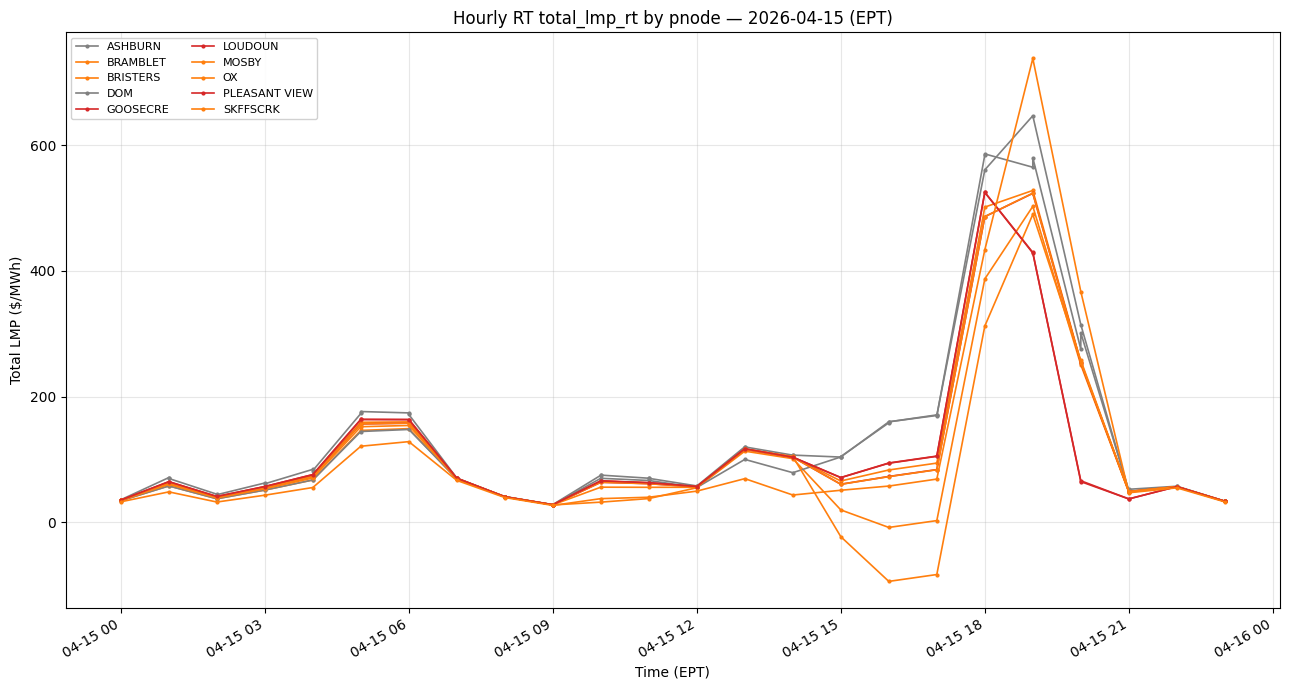


Daily summary by pnode:
                 mean     max     std  count
pnode_name                                  
ASHBURN        134.83  586.00  148.19     48
DOM            131.02  646.68  159.23     24
BRAMBLET       116.58  527.87  132.74     24
MOSBY          114.11  523.52  130.58     24
LOUDOUN        114.08  523.31  130.53     24
SKFFSCRK       111.89  737.79  167.19     24
PLEASANT VIEW  106.91  525.07  120.49     24
GOOSECRE       106.73  524.69  120.35     24
BRISTERS        96.36  502.57  121.93     24
OX              87.06  489.81  122.82     24


In [15]:
# (c) Plot the comparison. Visual sanity check: do the Loudoun-area
# transmission pnodes track each other? Does Ashburn 35KV LOAD track LOUDOUN?
# Where does the DOM zonal sit relative to the substation-level signals?
import matplotlib.pyplot as plt

df_plot = df_compare.copy()
df_plot["ts"] = pd.to_datetime(df_plot["datetime_beginning_ept"])

fig, ax = plt.subplots(figsize=(13, 7))
# Color by category
group_color = {
    **{n: "tab:red"    for n in PRIMARY_PNODES},
    **{n: "tab:orange" for n in LOUDOUN_SANITY},
    **{n: "tab:green"  for n in ASHBURN_BUSES},
    "DOM ZONE":           "tab:blue",
}
for pname, grp in df_plot.groupby("pnode_name"):
    grp = grp.sort_values("ts")
    color = group_color.get(pname, "gray")
    lw = 2.0 if pname == "DOM ZONE" else 1.2
    ls = "--" if pname == "DOM ZONE" else "-"
    ax.plot(grp["ts"], grp["total_lmp_rt"], label=pname,
            color=color, lw=lw, linestyle=ls, marker=".", markersize=4)

ax.set_title(f"Hourly RT total_lmp_rt by pnode — {SPIKE_DAY} (EPT)")
ax.set_xlabel("Time (EPT)")
ax.set_ylabel("Total LMP ($/MWh)")
ax.legend(loc="upper left", fontsize=8, ncols=2, framealpha=0.9)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table: daily mean / max / sd per pnode
summary = (
    df_plot.groupby("pnode_name")["total_lmp_rt"]
           .agg(["mean", "max", "std", "count"])
           .round(2)
           .sort_values("mean", ascending=False)
)
print("\nDaily summary by pnode:")
print(summary.to_string())

## 3. Pick a representative pnode for the LMP validation

For the spike we just need *one* working pnode_id to confirm the LMP feeds respond. Prefer an EHV bus (transmission-level) since that's what the proposal actually cares about.

In [6]:
candidates = df_pnodes
if "pnode_subtype" in candidates.columns:
    ehv = candidates[candidates["pnode_subtype"].astype(str).str.upper() == "EHV"]
    if not ehv.empty:
        candidates = ehv

assert not candidates.empty, "No pnodes resolved — pnode lookup must run first."
spike_pnode = candidates.iloc[0]
SPIKE_PNODE_ID = int(spike_pnode["pnode_id"])
print(f"Using pnode_id={SPIKE_PNODE_ID}  ({spike_pnode.get('pnode_name')!r}, "
      f"subtype={spike_pnode.get('pnode_subtype')}, voltage={spike_pnode.get('voltage_level')})")

Using pnode_id=35010371  ('PLEASANT VIEW', subtype=EHV, voltage=500 KV)


## 4. Hourly nodal LMP — one day at the picked pnode

In [7]:
with httpx.Client(headers=HEADERS, timeout=60.0) as client:
    df_hrl = fetch_feed(
        client,
        "rt_hrl_lmps",
        {
            "datetime_beginning_ept": f"{SPIKE_DAY_START} to {SPIKE_DAY_END}",
            "pnode_id": SPIKE_PNODE_ID,
            "row_is_current": "true",
        },
    )

print(f"rows: {len(df_hrl)}  (expected 24)")
print(f"columns: {list(df_hrl.columns)}")
df_hrl.head()

  [throttle] sleeping 10.7s to respect 6/min rate limit
rows: 24  (expected 24)
columns: ['datetime_beginning_utc', 'datetime_beginning_ept', 'pnode_id', 'pnode_name', 'voltage', 'equipment', 'type', 'zone', 'system_energy_price_rt', 'total_lmp_rt', 'congestion_price_rt', 'marginal_loss_price_rt', 'row_is_current', 'version_nbr']


,datetime_beginning_utc,datetime_beginning_ept,pnode_id,pnode_name,voltage,equipment,type,zone,system_energy_price_rt,total_lmp_rt,congestion_price_rt,marginal_loss_price_rt,row_is_current,version_nbr
0,2026-04-15T04:00:00,2026-04-15T00:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,25.66,35.36,8.87,0.84,True,1
1,2026-04-15T05:00:00,2026-04-15T01:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,28.66,64.70,35.19,0.85,True,1
2,2026-04-15T06:00:00,2026-04-15T02:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,21.44,41.12,19.09,0.60,True,1
3,2026-04-15T07:00:00,2026-04-15T03:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,26.65,57.01,29.67,0.69,True,1
4,2026-04-15T08:00:00,2026-04-15T04:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,31.27,75.97,43.88,0.81,True,1


## 5. 5-min nodal LMP — one day at the picked pnode (Standard window)

Filtered by `pnode_id`, **not** `zone` — the zone filter is disabled on this feed per the API guide. The spike date is well within the 186-day Standard window so `pnode_id` filtering is permitted.

In [8]:
with httpx.Client(headers=HEADERS, timeout=120.0) as client:
    df_5m = fetch_feed(
        client,
        "rt_fivemin_hrl_lmps",
        {
            "datetime_beginning_ept": f"{SPIKE_DAY_START} to {SPIKE_DAY_END}",
            "pnode_id": SPIKE_PNODE_ID,
            "row_is_current": "true",
        },
    )

print(f"rows: {len(df_5m)}  (expected ~288 for a non-DST day)")
print(f"columns: {list(df_5m.columns)}")
df_5m.head()

  [throttle] sleeping 10.5s to respect 6/min rate limit
rows: 288  (expected ~288 for a non-DST day)
columns: ['datetime_beginning_utc', 'datetime_beginning_ept', 'pnode_id', 'pnode_name', 'voltage', 'equipment', 'type', 'zone', 'system_energy_price_rt', 'total_lmp_rt', 'congestion_price_rt', 'marginal_loss_price_rt', 'row_is_current', 'version_nbr']


,datetime_beginning_utc,datetime_beginning_ept,pnode_id,pnode_name,voltage,equipment,type,zone,system_energy_price_rt,total_lmp_rt,congestion_price_rt,marginal_loss_price_rt,row_is_current,version_nbr
0,2026-04-15T04:00:00,2026-04-15T00:00:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,24.02,32.40,7.58,0.80,True,1
1,2026-04-15T04:05:00,2026-04-15T00:05:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,34.52,63.42,27.75,1.15,True,1
2,2026-04-15T04:10:00,2026-04-15T00:10:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,31.65,37.97,5.28,1.04,True,1
3,2026-04-15T04:15:00,2026-04-15T00:15:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,27.97,37.32,8.44,0.91,True,1
4,2026-04-15T04:20:00,2026-04-15T00:20:00,35010371,PLEASANT VIEW,500 KV,None,EHV,DOM,28.31,37.65,8.37,0.97,True,1


## 6. Hourly DOM-zone metered load — one day

In [9]:
with httpx.Client(headers=HEADERS, timeout=60.0) as client:
    df_load = fetch_feed(
        client,
        "hrl_load_metered",
        {
            "datetime_beginning_ept": f"{SPIKE_DAY_START} to {SPIKE_DAY_END}",
            "zone": "DOM",
        },
    )

print(f"rows: {len(df_load)}")
print(f"columns: {list(df_load.columns)}")
df_load.head()

  [throttle] sleeping 10.6s to respect 6/min rate limit
rows: 24
columns: ['datetime_beginning_utc', 'datetime_beginning_ept', 'nerc_region', 'mkt_region', 'zone', 'load_area', 'mw', 'is_verified']


,datetime_beginning_utc,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified
0,2026-04-15T04:00:00,2026-04-15T00:00:00,SERC,SOUTH,DOM,DOM,14211.523,False
1,2026-04-15T06:00:00,2026-04-15T02:00:00,SERC,SOUTH,DOM,DOM,13079.680,False
2,2026-04-15T14:00:00,2026-04-15T10:00:00,SERC,SOUTH,DOM,DOM,15542.927,False
3,2026-04-16T00:00:00,2026-04-15T20:00:00,SERC,SOUTH,DOM,DOM,19067.440,False
4,2026-04-15T11:00:00,2026-04-15T07:00:00,SERC,SOUTH,DOM,DOM,14366.774,False


## 7. Save spike outputs to parquet

In [10]:
outputs = [
    ("smoke_pnode_dom_1row", df_smoke),
    ("pnode_lookup_three_substations", df_pnodes),
    (f"rt_hrl_lmps__{SPIKE_DAY}__pnode_{SPIKE_PNODE_ID}", df_hrl),
    (f"rt_fivemin_hrl_lmps__{SPIKE_DAY}__pnode_{SPIKE_PNODE_ID}", df_5m),
    (f"hrl_load_metered__{SPIKE_DAY}__dom", df_load),
]
for name, df in outputs:
    out = DATA_RAW / f"spike__{name}.parquet"
    df.to_parquet(out, index=False)
    print(f"wrote {out.relative_to(PROJECT_ROOT)}  ({len(df):,} rows)")

wrote data/raw/spike__smoke_pnode_dom_1row.parquet  (1 rows)
wrote data/raw/spike__pnode_lookup_three_substations.parquet  (1 rows)
wrote data/raw/spike__rt_hrl_lmps__2026-04-15__pnode_35010371.parquet  (24 rows)
wrote data/raw/spike__rt_fivemin_hrl_lmps__2026-04-15__pnode_35010371.parquet  (288 rows)
wrote data/raw/spike__hrl_load_metered__2026-04-15__dom.parquet  (24 rows)


## 8. Volume sizing for the actual scope

Per `decisions.md` §2 the scope is tiered: 5-min nodal limited to the last ~6 months, hourly nodal for ~2 years (Standard window), zonal aggregates for older history. Update `n_pnodes` once the lookup above gives a real count.

In [11]:
n_pnodes = max(len(df_pnodes), 1)

# Each call costs ≥11s of wall time under the 6/min rate limit.
SECS_PER_CALL = MIN_REQUEST_INTERVAL_S

scopes = [
    ("rt_fivemin_hrl_lmps",  288, 186, n_pnodes,  "Standard window, nodal"),
    ("rt_hrl_lmps",           24, 731, n_pnodes,  "Standard window, nodal"),
    ("da_hrl_lmps",           24, 731, n_pnodes,  "Standard window, nodal"),
    ("rt_hrl_lmps (zonal)",   24, 365 * 5,    1,  "5-yr DOM zonal aggregate"),
    ("hrl_load_metered",      24, 365 * 5,    1,  "5-yr DOM zonal load"),
]

print(f"{'feed':28s} {'rows':>14s}  {'pages':>6s}  {'wall (s)':>9s}   note")
print("-" * 100)
for feed, n_per_day, days, pn, note in scopes:
    rows = n_per_day * days * pn
    pages = -(-rows // 50_000)
    # Date range cap is 366 days, so multi-year pulls must chunk by year.
    chunks = max(1, -(-days // 366))
    calls = max(pages, chunks)
    wall = calls * SECS_PER_CALL
    print(f"{feed:28s} {rows:>14,}  {calls:>6,}  {wall:>9,.0f}   {note}")

feed                                   rows   pages   wall (s)   note
----------------------------------------------------------------------------------------------------
rt_fivemin_hrl_lmps                  53,568       2         22   Standard window, nodal
rt_hrl_lmps                          17,544       2         22   Standard window, nodal
da_hrl_lmps                          17,544       2         22   Standard window, nodal
rt_hrl_lmps (zonal)                  43,800       5         55   5-yr DOM zonal aggregate
hrl_load_metered                     43,800       5         55   5-yr DOM zonal load


## 9. Open questions to verify from the run

After running, eyeball the outputs against these:

- [ ] **Envelope keys** — did `[debug]` print confirm `items` + `totalRows`? If not, update the fetcher key list and amend `pjm-api-constraints.md`.
- [ ] **Rate-limit headers** — did the response carry any `X-RateLimit-*` (or similar) headers? If yes, record what PJM actually advertises in `pjm-api-constraints.md`. (We already know the limit is 6/min from the portal; this is to confirm whether the limit is also surfaced per-response.)
- [ ] **Pnode lookup** — did each of the three substation names match real pnodes in zone=DOM? How many EHV vs LOAD vs other subtypes?
- [ ] **Hourly LMP** — exactly 24 rows? Field names match the API guide (`total_lmp_rt`, `congestion_price_rt`, `marginal_loss_price_rt`, `system_energy_price_rt`)? Both `_ept` and `_utc` timestamps present?
- [ ] **5-min LMP** — close to 288 rows? (Will be 276 / 300 on DST days; the chosen date is non-DST.) Same field shape as hourly?
- [ ] **DOM load** — 24 rows? Or many more (one per `load_area` within DOM)? Need to know whether to filter by `zone=DOM` or `load_area=DOM`.

Once these are answered, next deliverable is the acquisition module under `src/surg/acquisition/` — promote `fetch_feed`, add proper 429 backoff/retry, and switch to `download=true` for bulk pulls.